In [7]:
import json
import pandas as pd
from openai import OpenAI

client = OpenAI()

EVENT_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "doc_id": {"type": "string"},
        "language": {"type": "string", "enum": ["sr", "hr", "bs", "me", "und"]},
        "events": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "properties": {
                    "event_type": {
                        "type": "string",
                        "enum": [
                            "protest","traffic_blockade","institutional_blockade","march_walk",
                            "commemoration","strike_boycott","clash_police_action","arrest",
                            "investigation_charges_trial","resignation","government_response_policy",
                            "counter_protest","international_reaction","election","school_closure","injury_death","university_administration_action", "other"
                        ]
                    },
                    "trigger": {"type": ["string", "null"]},
                    "locations": {"type": "array", "items": {"type": "string"}},
                    "actors": {"type": "array", "items": {"type": "string"}},
                    "time_mentions": {"type": "array", "items": {"type": "string"}},
                    "confidence": {"type": "number", "minimum": 0, "maximum": 1},
                    "notes": {"type": ["string", "null"]}
                },
                "required": ["event_type", "trigger", "locations", "actors", "time_mentions", "confidence", "notes"]
            }
        }
    },
    "required": ["doc_id", "language", "events"]
}

SYSTEM_INSTRUCTIONS = """You extract events from Serbian/Croatian/Bosnian/Montenegrin news text.
Rules:
- Output MUST follow the JSON schema exactly.
- Do NOT invent details. If a field is not explicitly supported by the text, use null (or empty list).
- Keep strings in the original script/language; do not translate.
- If there are no events, return events: [].
- Return one result per DOC_ID.
"""

def extract_events(doc_id: str, text: str, model: str = "gpt-4o-2024-08-06"):
    resp = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": SYSTEM_INSTRUCTIONS},
            {"role": "user", "content": f"doc_id: {doc_id}\n\nTEXT:\n{text}"}
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "event_extraction",
                "strict": True,
                "schema": EVENT_SCHEMA
            }
        },
        store=False,
    )
    return json.loads(resp.output_text)

# --------- NEW: batch wrapper (minimal addition) ---------
BATCH_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "properties": {
        "results": {
            "type": "array",
            "items": EVENT_SCHEMA
        }
    },
    "required": ["results"]
}

def extract_events_batch(docs, model: str = "gpt-4o-2024-08-06"):
    """
    docs: list of (doc_id, text)
    returns: list of dicts matching EVENT_SCHEMA
    """
    payload = "\n\n".join(
        [f"### DOC {i}\nDOC_ID: {doc_id}\nTEXT:\n{text}"
         for i, (doc_id, text) in enumerate(docs, start=1)]
    )

    resp = client.responses.create(
        model=model,
        input=[
            {"role": "system", "content": SYSTEM_INSTRUCTIONS},
            {"role": "user", "content": payload}
        ],
        text={
            "format": {
                "type": "json_schema",
                "name": "event_extraction_batch",
                "strict": True,
                "schema": BATCH_SCHEMA
            }
        },
        store=False,
    )

    out = json.loads(resp.output_text)
    return out["results"]

def chunk_list(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]




In [6]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")


In [9]:
import pandas as pd
df= pd.read_csv("/content/n1.csv")

In [ ]:
import os
key = os.environ["OPENAI_API_KEY"]


In [114]:
n1["doc_id"] = n1.index.astype(str)

/tmp/ipython-input-2294152561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n1["doc_id"] = n1.index.astype(str)


In [38]:

df["doc_id"] = df.index.astype(str)


pairs = list(zip(df["doc_id"], df["headline"].astype(str)))

all_results = []
for batch in chunk_list(pairs[17522:], 100):  # for headlines, 100 is a reasonable start
    all_results.extend(extract_events_batch(batch))

res_df = pd.DataFrame(all_results)  # columns: doc_id, language, events
df = df.merge(res_df, on="doc_id", how="left")

df.head()

/tmp/ipython-input-3498208884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["doc_id"] = df.index.astype(str)


KeyboardInterrupt: 

In [61]:
for batch in chunk_list(pairs[28351:], 100):  # for headlines, 100 is a reasonable start
    all_results.extend(extract_events_batch(batch))

res_df = pd.DataFrame(all_results)  # columns: doc_id, language, events
df = df.merge(res_df, on="doc_id", how="left")

df.head()

,@type,headline,url,datePublished,author,doc_id,Unnamed: 0,language,events
0,NewsArticle,Iskliznuli vagoni kod Kosjerića i dalje stoje ...,/vesti/iskliznuli-vagoni-kod-kosjerica-i-dalje...,2026-01-18 10:33:05.157429+00:00,"{'@type': 'Person', 'name': 'N1 Beograd'}",0,NaN,NaN,NaN
1,NewsArticle,Roditelji zabrinuti za bezbednost dece u hali ...,/vesti/roditelji-zabrinuti-za-bezbednost-dece-...,2026-01-18 10:21:34.757353+00:00,"{'@type': 'Person', 'name': 'N1 Beograd'}",1,NaN,NaN,NaN
2,NewsArticle,Novi DSS neće na sastanak s evroparlamentarcim...,/vesti/novi-dss-nece-na-sastanak-s-evroparlame...,2026-01-18 10:03:18.076653+00:00,"{'@type': 'Person', 'name': 'Beta '}",2,NaN,NaN,NaN
3,NewsArticle,Poskupele auto-škole u Nišu: Da li je cena od ...,/vesti/poskupele-auto-skole-u-nisu-kakva-je-si...,2026-01-18 09:11:13.590901+00:00,"{'@type': 'Person', 'name': 'N1 Beograd'}",3,NaN,NaN,NaN
4,NewsArticle,Ministarstvo razmatra skraćenje časova na 30 m...,/vesti/ministarstvo-prosvete-skracivanje-casov...,2026-01-18 08:38:44.004672+00:00,"{'@type': 'Person', 'name': 'Beta '}",4,NaN,NaN,NaN


In [58]:
all_results=all_results.to_dict(orient='records')

In [142]:
both= both[both["events"].notna() & both["events"].astype(str).str.strip().ne("").copy()]


In [139]:
both= both[both["events"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

In [143]:
protests = both[both["events"].apply(lambda evs: any(e.get("event_type") == "protest" for e in evs))].copy()


AttributeError: 'str' object has no attribute 'get'

In [144]:
both['events']

,events
0,[]
1,[]
2,[]
3,[]
4,"[{'event_type': 'government_response_policy', ..."
...,...
24078,"[{'event_type': 'injury_death', 'trigger': 'Iz..."
24079,"[{'event_type': 'strike_boycott', 'trigger': '..."
24080,"[{'event_type': 'commemoration', 'trigger': 'Š..."
24081,"[{'event_type': 'injury_death', 'trigger': 'Dv..."


In [150]:
import ast

def has_event(evs,event="protest"):
    if not isinstance(evs, list):
        return False
    for e in evs:

        if isinstance(e, str):
            try:
                e = ast.literal_eval(e)
            except Exception:
                continue
        if isinstance(e, dict) and e.get("event_type") == event:
            return True
    return False

protests = both[both["events"].apply(has_event)].copy()
protest_dates=pd.to_datetime(protests["datePublished"],format="mixed" ,errors="coerce")

In [156]:
def has_event(evs, event_type):
    return isinstance(evs, list) and any(
        isinstance(e, dict) and e.get("event_type") == event_type
        for e in evs
    )

investigation_charges_trial = both[
    both["events"].apply(lambda evs: has_event(evs, "investigation_charges_trial"))
].copy()


In [158]:

investigation_charges_trial_dates=pd.to_datetime(investigation_charges_trial ["datePublished"],format="mixed" ,errors="coerce")

In [91]:
import pandas as pd

dates = [
    "2025-05-24 12:24:19.140548+00:00",
    "2024-10-31 17:33:46+00:00",
    "2025-05-24 07:06:30.151006+00:00",
]

dt = pd.to_datetime(dates, format="mixed" ,errors="coerce")  # parses mixed formats

# choose ONE output format (example: ISO without microseconds)
out = dt.strftime("%Y-%m-%d %H:%M:%S%z")  # e.g. 2025-05-24 12:24:19+0000

out.tolist()

['2025-05-24 12:24:19+0000',
 '2024-10-31 17:33:46+0000',
 '2025-05-24 07:06:30+0000']

In [88]:
from datetime import datetime

dt = datetime.fromisoformat("2024-10-31 19:30:51+00:00")
dt

datetime.datetime(2024, 10, 31, 19, 30, 51, tzinfo=datetime.timezone.utc)

In [92]:
protest_dates=pd.to_datetime(protests["datePublished"],format="mixed" ,errors="coerce")

In [97]:
protest_dates=pd.DataFrame(protest_dates)

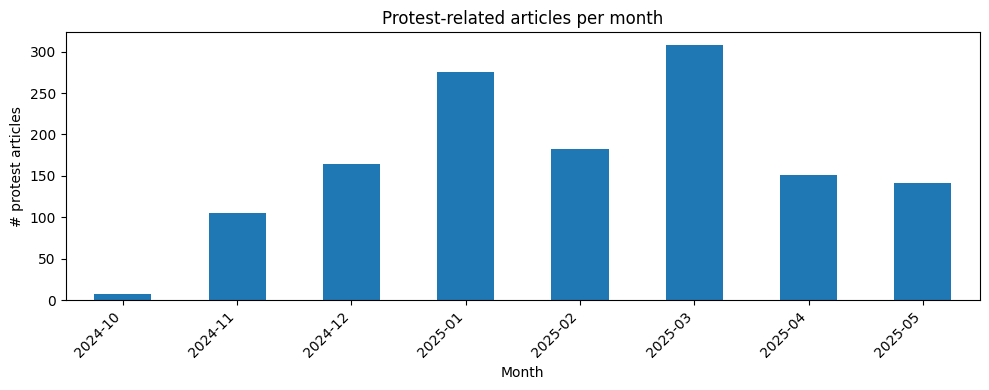

In [100]:
monthly_counts = (
    protest_dates
    .set_index("datePublished")
    .groupby(pd.Grouper(freq="MS"))
    .size()
)

monthly_counts.index = monthly_counts.index.strftime("%Y-%m")  # <-- key line

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
monthly_counts.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("# protest articles")
plt.title("Protest-related articles per month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

monthly_counts = (
    investigationt_dates
    .set_index("datePublished")
    .groupby(pd.Grouper(freq="MS"))
    .size()
)

monthly_counts.index = monthly_counts.index.strftime("%Y-%m")  # <-- key line

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
monthly_counts.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("# protest articles")
plt.title("Protest-related articles per month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


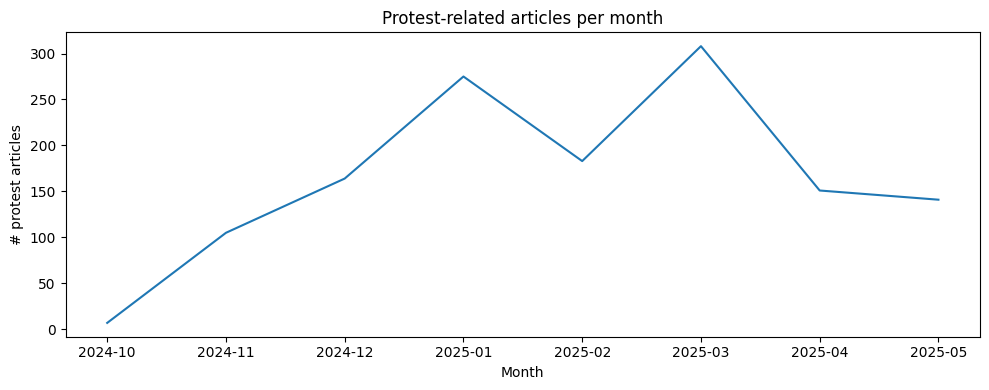

In [101]:
plt.figure(figsize=(10,4))
monthly_counts.plot()
plt.xlabel("Month")
plt.ylabel("# protest articles")
plt.title("Protest-related articles per month")
plt.tight_layout()
plt.show()


In [109]:
event_results=pd.read_csv("/content/event_results.csv")

In [110]:
n1=pd.read_csv("/content/n1.csv")

In [113]:
event_results

,Unnamed: 0,doc_id,language,events
0,0,0,sr,[]
1,1,1,sr,[]
2,2,2,sr,[]
3,3,3,sr,[]
4,4,4,sr,"[{'event_type': 'government_response_policy', ..."
...,...,...,...,...
17518,17518,18553,sr,[]
17519,17519,18554,und,[]
17520,17520,18555,sr,[]
17521,17521,18556,sr,[]


In [122]:
n1=n1.iloc[:17523]
n1=pd.concat([n1,event_results],axis=1)



In [141]:
n1 = n1.loc[:, ~n1.columns.duplicated()].copy()
df = df.loc[:, ~df.columns.duplicated()].copy()

both = pd.concat([n1, df], axis=0, ignore_index=True, sort=False)


In [34]:
df=df[:34700]

In [35]:
pairs = list(zip(df["doc_id"], df["headline"].astype(str)))

In [25]:
pd.DataFrame(all_results).to_csv("event_results.csv")

In [43]:

all_results[0]


'Unnamed: 0'

In [ ]:
df.to_csv("events_extracted.csv")

In [47]:
import pandas as pd
all_results= pd.read_csv("/content/event_results.csv")

In [50]:
pd.DataFrame(all_results)

,Unnamed: 0,doc_id,language,events
0,0,0,sr,[]
1,1,1,sr,[]
2,2,2,sr,[]
3,3,3,sr,[]
4,4,4,sr,"[{'event_type': 'government_response_policy', ..."
...,...,...,...,...
17518,17518,18553,sr,[]
17519,17519,18554,und,[]
17520,17520,18555,sr,[]
17521,17521,18556,sr,[]


In [ ]:
import pandas as pd

events=pd.read_csv("/content/events_extracted_correct.csv", sep=";")


In [ ]:

accuracy = events["event_correct"].mean()
print(accuracy)

0.9320987654320988


,events
0,"[{'event_type': 'international_reaction', 'tri..."
1,"[{'event_type': 'other', 'trigger': 'sprovodi ..."
2,"[{'event_type': 'arrest_detention', 'trigger':..."
3,"[{'event_type': 'clash_police_action', 'trigge..."
4,[]
...,...
136,"[{'event_type': 'investigation_charges_trial',..."
137,"[{'event_type': 'clash_police_action', 'trigge..."
138,"[{'event_type': 'institutional_blockade', 'tri..."
139,"[{'event_type': 'clash_police_action', 'trigge..."


In [152]:
import pandas as pd
import ast

def parse_events(x):

    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        x = x.strip()
        if x == "" or x.lower() == "nan":
            return []
        try:
            return ast.literal_eval(x)
        except Exception:
            return []

    return []

both = both.copy()
both["events"] = both["events"].apply(parse_events)


ev = both[both["events"].apply(len) > 0].copy()


ev = ev.explode("events", ignore_index=True)


ev["event_type"] = ev["events"].apply(lambda d: d.get("event_type") if isinstance(d, dict) else None)

counts = ev["event_type"].value_counts(dropna=False)
counts


,count
event_type,
protest,2408
investigation_charges_trial,1392
arrest,1266
injury_death,1152
clash_police_action,1115
institutional_blockade,1060
government_response_policy,843
other,776
international_reaction,656


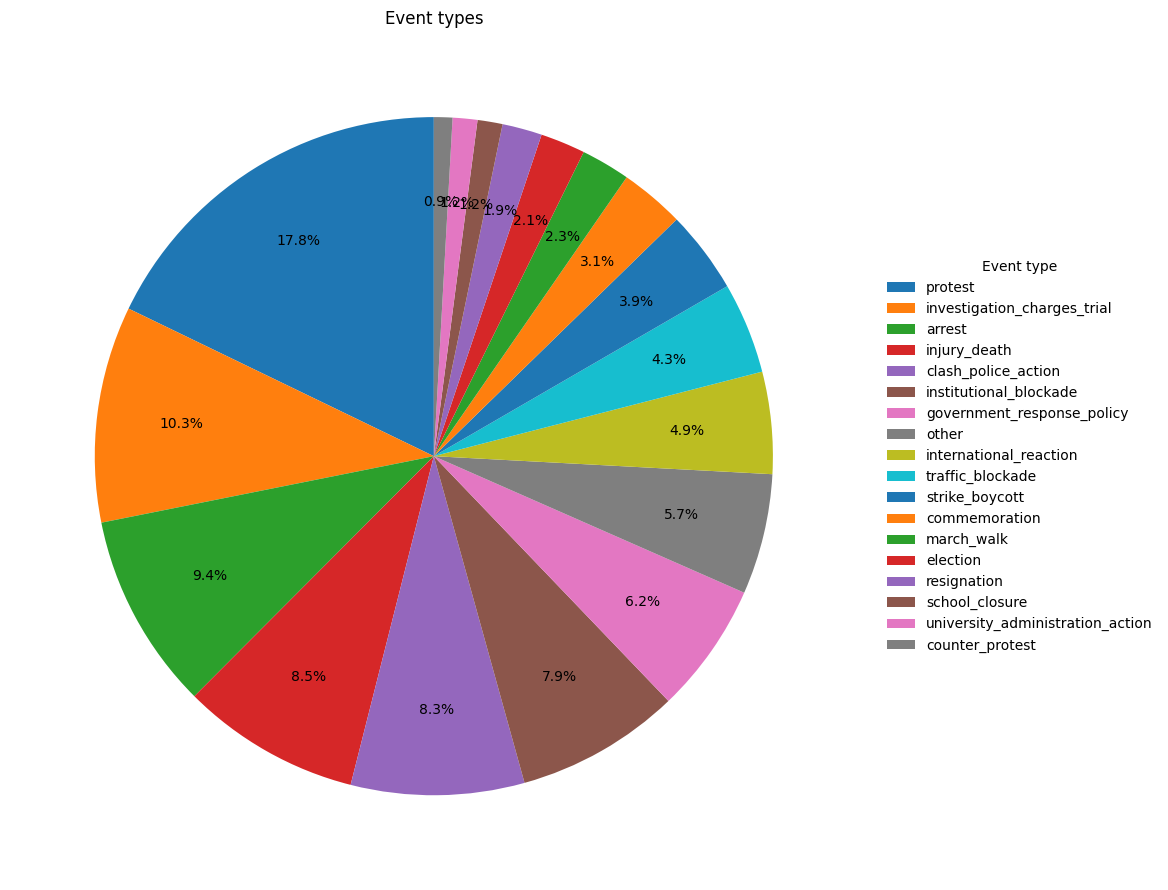

In [153]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 9))

wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 10},
)

ax.legend(
    wedges,
    counts.index,
    title="Event type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set_title("Event types")
plt.tight_layout()
plt.show()


In [159]:
import pandas as pd

EVENT_TYPES = [
    "protest",
    "investigation_charges_trial",
    "arrest",
    "injury_death",
    "clash_police_action",
    "institutional_blockade",
    "government_response_policy",
]

# 1) Ensure date is datetime
both = both.copy()
both["datePublished"] = pd.to_datetime(both["datePublished"], utc=True, errors="coerce", format="mixed")
both = both.dropna(subset=["datePublished"])

# 2) Explode events to event-level rows
ev = both.explode("events", ignore_index=True)

# 3) Extract event_type safely
ev["event_type"] = ev["events"].apply(lambda d: d.get("event_type") if isinstance(d, dict) else None)

# 4) Keep only the event types you care about
ev = ev[ev["event_type"].isin(EVENT_TYPES)].copy()

# 5) Month bucket
ev["month"] = ev["datePublished"].dt.to_period("M").astype(str)

# 6) Count events per month per type
monthly = (
    ev.groupby(["month", "event_type"])
      .size()
      .reset_index(name="count")
      .sort_values("month")
)


/tmp/ipython-input-433478571.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ev["month"] = ev["datePublished"].dt.to_period("M").astype(str)


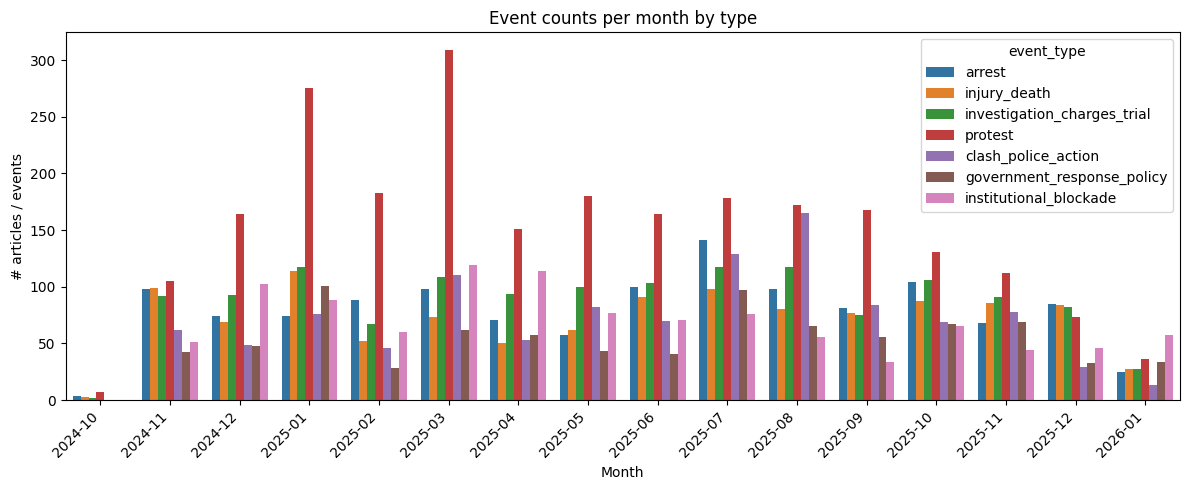

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.barplot(data=monthly, x="month", y="count", hue="event_type")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("# articles / events")
plt.title("Event counts per month by type")
plt.tight_layout()
plt.show()


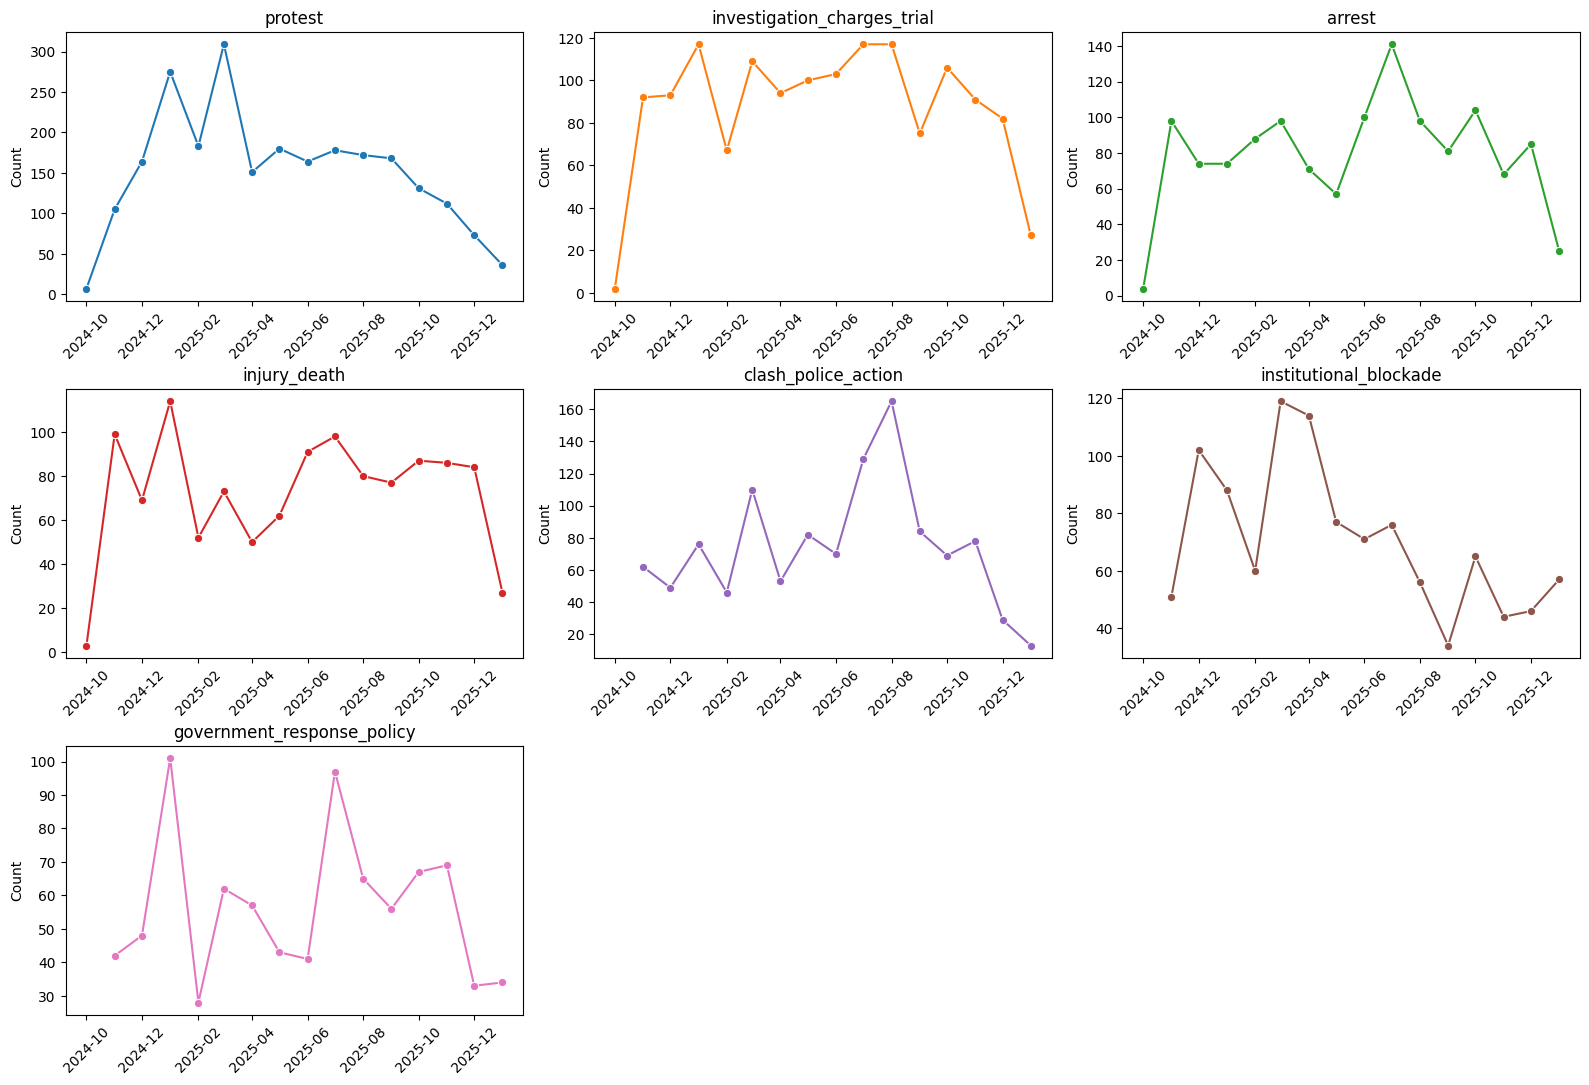

In [166]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly = monthly.copy()
monthly["month_dt"] = pd.to_datetime(monthly["month"] + "-01")

n = len(EVENT_TYPES)
cols = 3
rows = math.ceil(n / cols)

palette = dict(zip(EVENT_TYPES, sns.color_palette(n_colors=len(EVENT_TYPES))))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows), sharex=True, sharey=False)
axes = axes.flatten()

for ax, et in zip(axes, EVENT_TYPES):
    m = monthly[monthly["event_type"] == et].sort_values("month_dt")

    sns.lineplot(data=m, x="month_dt", y="count", ax=ax, marker="o", color=palette[et])

    ax.set_title(et)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)


for ax in axes[len(EVENT_TYPES):]:
    ax.axis("off")


for ax in axes[:len(EVENT_TYPES)]:
    ax.tick_params(axis="x", labelbottom=True)

fig.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.show()


In [ ]:
lemmatized=pd.read_csv("/content/n1_lemmatized.csv")

In [ ]:
lemmatized=lemmatized.sample(n=500, random_state=0)

In [ ]:
lem=lemmatized["lemmatized"]

In [ ]:
non_lem=lemmatized["headline"]

In [ ]:
lem["doc_id"] = lem.index.astype(str)


pairs = list(zip(lem["doc_id"], lem.astype(str)))
print(pairs)

[('1814', 'Vučević nazvati idiotima čovjek koji sebe boriti za generalštab : " pokušaj uništavanje Srbija " '), ('29824', 'održan protest poljoprivrednik u Badovinc : poručili - nemojte mi stajati na put '), ('7628', 'porodica student za N1 : Bogdan pretučen kod pionirski park , na pregled u urgentn centar '), ('5745', '( VIDEO ) inspekcija ponovo na vrato radnja aktivista iz užica : " poslušnik vršiti represija nad građanin " '), ('231', 'Selaković o generalštabu : nemati trunčica korupcija u onaj što sebe politički montirati kolega i ja '), ('31982', '" dekan mi pretiti disciplinski prijava " : nastavljen blokada filozofski u Novi Sad '), ('21601', '" postojati opasnost za završetak školski godina " : u forum srednji škola predlagati sažimanje gradiv '), ('27727', 'nov američki administracija protiv madurovi režim , kako htjeti gledati na veza Vučić sa Venecuela ? '), ('9826', 'roditelj , nastavnik i učenik ispred pete beogradski gimnazija , protest zbog odmazda nad prosvetni radnik 

In [ ]:
lem=pd.DataFrame(lem)
lem

,lemmatized
1814,Vučević nazvati idiotima čovjek koji sebe bori...
29824,održan protest poljoprivrednik u Badovinc : po...
7628,porodica student za N1 : Bogdan pretučen kod p...
5745,( VIDEO ) inspekcija ponovo na vrato radnja ak...
231,Selaković o generalštabu : nemati trunčica kor...
...,...
11158,napadnuta dvojica novinar u incident u Novi Sa...
31214,BIRN : Srbija uvoziti oprema za masovan nadzor...
31511,"objavljeni dobitnik nagrada "" Srđan Aleksić "" ..."
13379,"ministar Darko Glišić zapretiti "" blokaderima ..."


In [ ]:
lem=pd.DataFrame(lem)
lem["doc_id"] = lem.index.astype(str)


pairs = list(zip(lem["doc_id"], lem["lemmatized"].astype(str)))
print(pairs)
all_results = []
for batch in chunk_list(pairs, 100):
    all_results.extend(extract_events_batch(batch))

res_df = pd.DataFrame(all_results)
lem= lem.merge(res_df, on="doc_id", how="left")

lem.head()

[('1814', 'Vučević nazvati idiotima čovjek koji sebe boriti za generalštab : " pokušaj uništavanje Srbija " '), ('29824', 'održan protest poljoprivrednik u Badovinc : poručili - nemojte mi stajati na put '), ('7628', 'porodica student za N1 : Bogdan pretučen kod pionirski park , na pregled u urgentn centar '), ('5745', '( VIDEO ) inspekcija ponovo na vrato radnja aktivista iz užica : " poslušnik vršiti represija nad građanin " '), ('231', 'Selaković o generalštabu : nemati trunčica korupcija u onaj što sebe politički montirati kolega i ja '), ('31982', '" dekan mi pretiti disciplinski prijava " : nastavljen blokada filozofski u Novi Sad '), ('21601', '" postojati opasnost za završetak školski godina " : u forum srednji škola predlagati sažimanje gradiv '), ('27727', 'nov američki administracija protiv madurovi režim , kako htjeti gledati na veza Vučić sa Venecuela ? '), ('9826', 'roditelj , nastavnik i učenik ispred pete beogradski gimnazija , protest zbog odmazda nad prosvetni radnik 

,lemmatized,doc_id,language,events
0,Vučević nazvati idiotima čovjek koji sebe bori...,1814,sr,[]
1,održan protest poljoprivrednik u Badovinc : po...,29824,sr,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,porodica student za N1 : Bogdan pretučen kod p...,7628,sr,"[{'event_type': 'other', 'trigger': 'pretučen'..."
3,( VIDEO ) inspekcija ponovo na vrato radnja ak...,5745,sr,"[{'event_type': 'investigation_charges_trial',..."
4,Selaković o generalštabu : nemati trunčica kor...,231,sr,[]


In [ ]:
lem

,lemmatized,doc_id,language,events
0,Vučević nazvati idiotima čovjek koji sebe bori...,1814,sr,[]
1,održan protest poljoprivrednik u Badovinc : po...,29824,sr,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,porodica student za N1 : Bogdan pretučen kod p...,7628,sr,"[{'event_type': 'other', 'trigger': 'pretučen'..."
3,( VIDEO ) inspekcija ponovo na vrato radnja ak...,5745,sr,"[{'event_type': 'investigation_charges_trial',..."
4,Selaković o generalštabu : nemati trunčica kor...,231,sr,[]
...,...,...,...,...
496,napadnuta dvojica novinar u incident u Novi Sa...,11158,NaN,NaN
497,BIRN : Srbija uvoziti oprema za masovan nadzor...,31214,NaN,NaN
498,"objavljeni dobitnik nagrada "" Srđan Aleksić "" ...",31511,NaN,NaN
499,"ministar Darko Glišić zapretiti "" blokaderima ...",13379,NaN,NaN


In [ ]:

n_nan = lem["events"].isna().sum()


n_empty_list = lem["events"].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()


print("NaN:", n_nan)
print("Empty []:", n_empty_list)



NaN: 104
Empty []: 211


In [ ]:
res_df = pd.DataFrame(all_results)

In [ ]:
res_df

,doc_id,language,events
0,1814,und,[]
1,29824,und,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,7628,und,"[{'event_type': 'clash_police_action', 'trigge..."
3,5745,und,"[{'event_type': 'investigation_charges_trial',..."
4,231,und,[]
...,...,...,...
195,13917,sr,"[{'event_type': 'clash_police_action', 'trigge..."
196,5815,sr,[]
197,10476,sr,[]
198,27634,sr,"[{'event_type': 'clash_police_action', 'trigge..."


In [ ]:
lem= pd.DataFrame(lem).merge(res_df, on="doc_id", how="left")

lem.head()

KeyError: 'doc_id'

In [ ]:


lemmatized["doc_id"] = lemmatized.index.astype(str)


pairs = list(zip(lemmatized["doc_id"], lemmatized['headline'].astype(str)))



In [ ]:
all_results = []
for batch in chunk_list(pairs, 100):
    all_results.extend(extract_events_batch(batch))

res_df = pd.DataFrame(all_results)
lemmatized= lemmatized.merge(res_df, on="doc_id", how="left")

lemmatized.head()

,Unnamed: 0,headline,url,datePublished,author,Related,Scores,spacy_doc,lemmatized,ner,doc_id,language,events
0,1814,Vučević nazvao idiotima ljude koji se bore za ...,/vesti/vucevic-nazvao-idiotima-ljude-koji-se-b...,2025-12-19 09:29:01.043365+00:00,"{'@type': 'Person', 'name': 'Beta '}",False,"[0.7954736948013306, 0.20452630519866943]",Vučević nazvao idiotima ljude koji se bore za ...,Vučević nazvati idiotima čovjek koji sebe bori...,"[{'entity_group': 'PER', 'score': np.float32(0...",1814,sr,[]
1,29824,Održan protest poljoprivrednika u Badovincima:...,/vesti/blog-uzivo-poljoprivrednici-protest/,2024-12-29 11:52:31+00:00,"{'@type': 'Person', 'name': 'nova.rs '}",False,"[0.9991506338119507, 0.0008493904606439173]",Održan protest poljoprivrednika u Badovincima:...,održan protest poljoprivrednik u Badovinc : po...,"[{'entity_group': 'LOC', 'score': np.float32(0...",29824,sr,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,7628,Porodica studenta za N1: Bogdan pretučen kod P...,/vesti/studenti-u-blokadi-kolega-nam-je-pretuc...,2025-10-01 19:37:47.112507+00:00,"{'@type': 'Person', 'name': 'N1 Beograd'}",False,"[0.7599595785140991, 0.24004043638706207]",Porodica studenta za N1: Bogdan pretučen kod P...,porodica student za N1 : Bogdan pretučen kod p...,"[{'entity_group': 'ORG', 'score': np.float32(0...",7628,sr,"[{'event_type': 'clash_police_action', 'trigge..."
3,5745,(VIDEO) Inspekcija ponovo na vratima radnje ak...,/vesti/video-inspekcija-ponovo-na-vratima-radn...,2025-10-28 09:34:38.831863+00:00,"{'@type': 'Person', 'name': 'N1 Beograd'}",False,"[0.9953579306602478, 0.00464206887409091]",(VIDEO) Inspekcija ponovo na vratima radnje ak...,( VIDEO ) inspekcija ponovo na vrato radnja ak...,[],5745,sr,[]
4,231,Selaković o Generalštabu: Nema trunčice korupc...,/vesti/selakovic-o-generalstabu-nema-truncice-...,2026-01-14 16:22:15.944004+00:00,"{'@type': 'Person', 'name': 'Beta '}",True,"[0.5492145419120789, 0.45078548789024353]",Selaković o Generalštabu: Nema trunčice korupc...,Selaković o generalštabu : nemati trunčica kor...,"[{'entity_group': 'PER', 'score': np.float32(0...",231,sr,[]


In [ ]:
non_lem_ev=lemmatized["events"]

In [ ]:

n_nan = non_lem_ev.isna().sum()


n_empty_list =  non_lem_ev.apply(lambda x: isinstance(x, list) and len(x) == 0).sum()


print("NaN:", n_nan)
print("Empty []:", n_empty_list)

NaN: 148
Empty []: 260


In [ ]:

lem = lem[lem["events"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

In [ ]:
non_lem = non_lem_ev[non_lem_ev.apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()

In [ ]:
non_lem

,events
1,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,"[{'event_type': 'clash_police_action', 'trigge..."
5,"[{'event_type': 'institutional_blockade', 'tri..."
8,"[{'event_type': 'protest_rally', 'trigger': 'p..."
12,"[{'event_type': 'vigil_commemoration', 'trigge..."
...,...
511,"[{'event_type': 'institutional_blockade', 'tri..."
513,"[{'event_type': 'vigil_commemoration', 'trigge..."
514,"[{'event_type': 'election', 'trigger': 'izborn..."
516,"[{'event_type': 'election', 'trigger': 'glasov..."


In [ ]:
lem["events"]

,events
1,"[{'event_type': 'protest_rally', 'trigger': 'p..."
2,"[{'event_type': 'other', 'trigger': 'pretučen'..."
3,"[{'event_type': 'investigation_charges_trial',..."
5,"[{'event_type': 'institutional_blockade', 'tri..."
8,"[{'event_type': 'protest_rally', 'trigger': 'p..."
...,...
452,"[{'event_type': 'resignation_dismissal', 'trig..."
454,"[{'event_type': 'government_response_policy', ..."
455,"[{'event_type': 'government_response_policy', ..."
458,"[{'event_type': 'government_response_policy', ..."


In [ ]:
import pandas as pd
import ast



lem["events"] = lem["events"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


ev = lem[lem["events"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()


ev = ev.explode("events")


ev["event_type"] = ev["events"].apply(lambda d: d.get("event_type") if isinstance(d, dict) else None)

counts = ev["event_type"].value_counts()
counts

,count
event_type,
protest_rally,34
arrest_detention,22
government_response_policy,21
investigation_charges_trial,20
other,19
clash_police_action,12
institutional_blockade,11
traffic_blockade,9
strike_boycott,8


In [ ]:
import pandas as pd
import ast



lemmatized["events"] = lemmatized["events"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


ev = lem[lemmatized["events"].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()


ev = ev.explode("events")


ev["event_type"] = ev["events"].apply(lambda d: d.get("event_type") if isinstance(d, dict) else None)

counts = ev["event_type"].value_counts()
counts

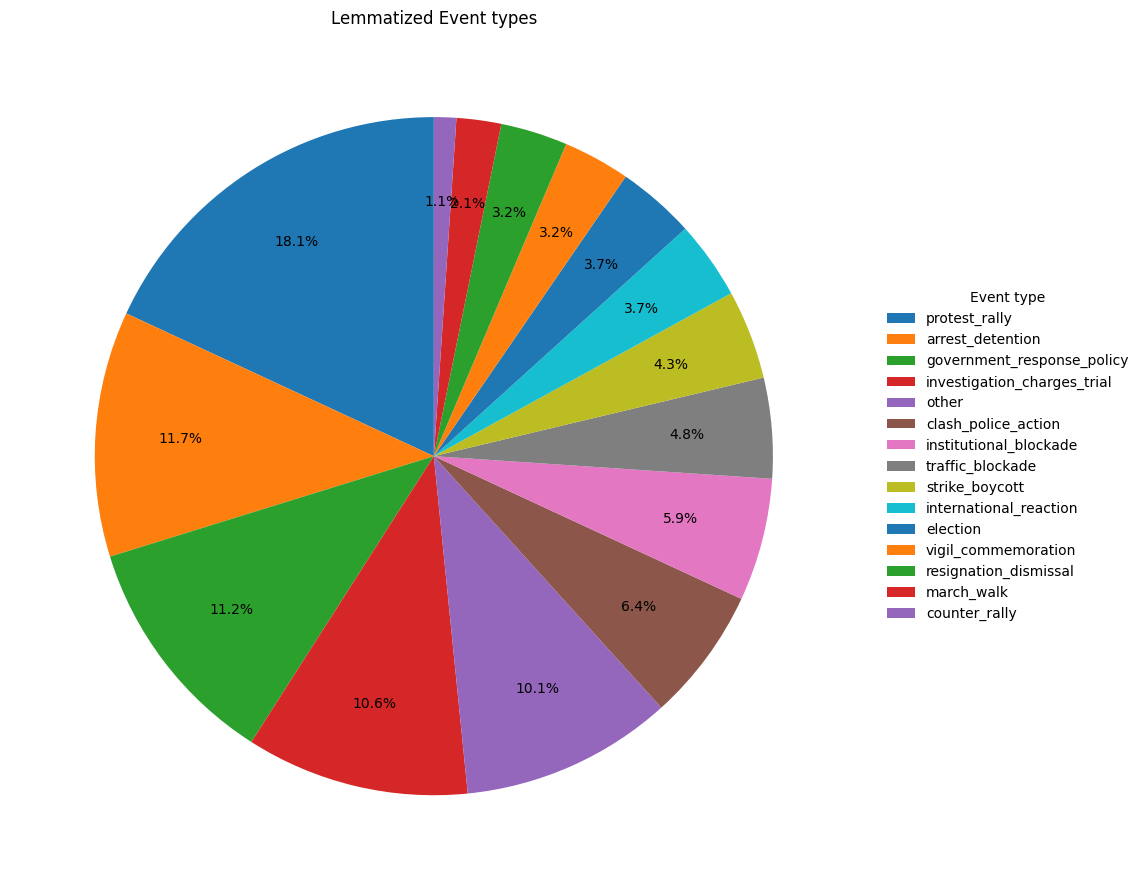

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 9))

wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 10},
)

ax.legend(
    wedges,
    counts.index,
    title="Event type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set_title("Lemmatized Event types")
plt.tight_layout()
plt.show()


In [ ]:
non_lem = non_lem.apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

In [ ]:
import pandas as pd
import ast





ev = non_lem[non_lem.apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()


ev = ev.explode()


ev["event_type"] = ev.apply(lambda d: d.get("event_type") if isinstance(d, dict) else None)

counts = ev["event_type"].value_counts()
counts

,count
events,
protest_rally,29
arrest_detention,14
investigation_charges_trial,12
clash_police_action,10
other,8
institutional_blockade,7
election,7
government_response_policy,6
march_walk,6


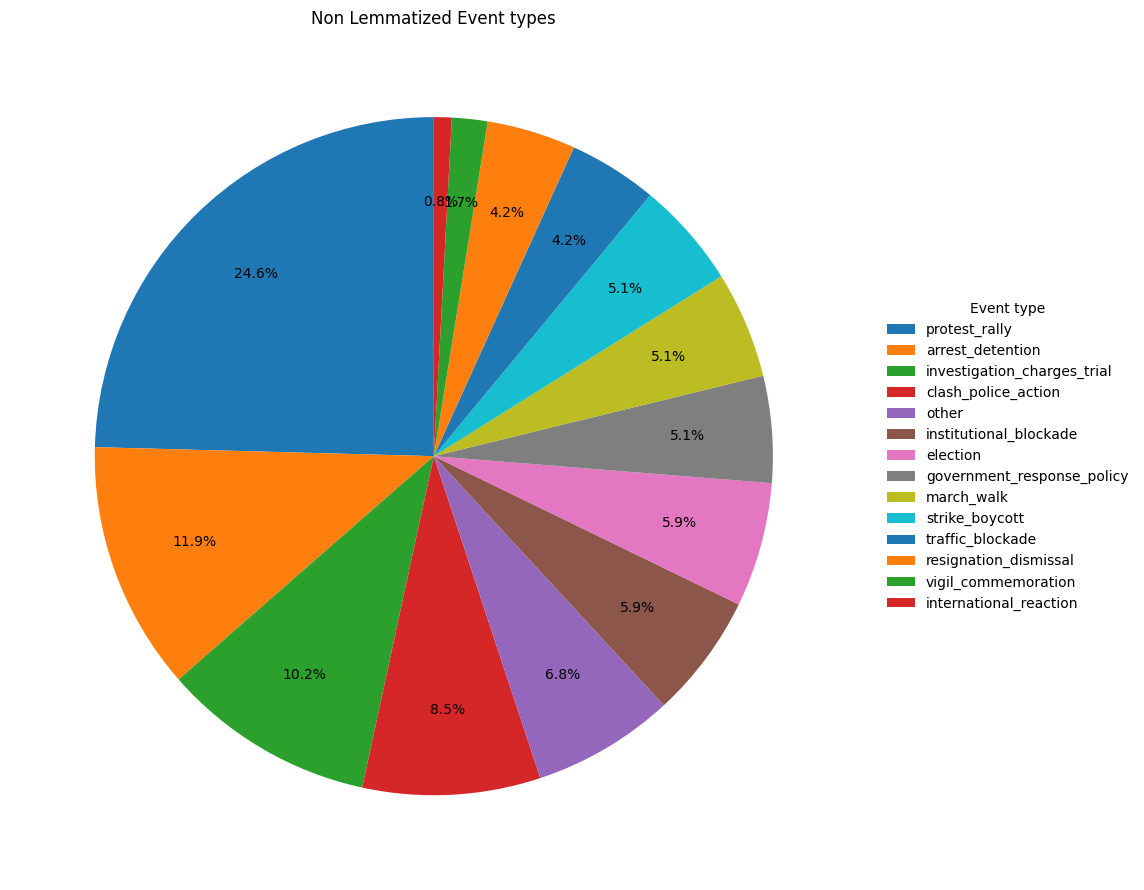

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 9))

wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 10},
)

ax.legend(
    wedges,
    counts.index,
    title="Event type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set_title("Non Lemmatized Event types")
plt.tight_layout()
plt.show()
